In [6]:
# Newton's equation: F = (GMm)/r^2, for M, we will be using Solar Masses; for r, we will be using Schwarzschild radius; we will be ignoring m to find the acceleration (since I won't be using a relative body to calculate the force)
# Schwarzschild radius: R = (2GM)/c^2, we will also use Solar Masses for M, but we will use 2.998 x 10^8 m/s for c

# Imports #
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.constants as const

## DataFrame of Black Holes ##

# Define Data Frame #
data = {'Stellar Black Holes': ['Gaia BH1', 'Cygnus X-1','V404 Cygni', 'GRP J1655-40', 'A0620-00', 'GW150914', 'Gaia BH3', 'IC 10 X-1', 'M33 X-7', 'GRS 1915+105', 'SS 433', 'XTE J1650-500', 'GS 2000+25'],
             'Solar Mass': [9.62, 21.2, 9, 6.3, 6.6, 62, 33, 23, 15.7, 14, 16, 3.8, 8.5]
             }
df = pd.DataFrame(data)

# Add Schwarzschild Radius #
new_G = const.G * (2 * 10 ** 30) # Convert G into solar masses
df['Radius (Logarithmic: m)'] = np.log((2 * 3 * new_G * df['Solar Mass']) / (np.square(const.c))) # We multiply by 3, since it is usually 3 km per solar mass

# Add Gravitational Acceleration #
df['Gravitational Acceleration (Logarithmic: N/kg)'] = np.log((new_G * df['Solar Mass']) / np.square(df['Radius (Logarithmic: m)']))

# View DataFrame #
print(df)

   Stellar Black Holes  Solar Mass  Radius (Logarithmic: m)  \
0             Gaia BH1        9.62                11.358930   
1           Cygnus X-1       21.20                12.149087   
2           V404 Cygni        9.00                11.292310   
3         GRP J1655-40        6.30                10.935635   
4             A0620-00        6.60                10.982155   
5             GW150914       62.00                13.222220   
6             Gaia BH3       33.00                12.591593   
7            IC 10 X-1       23.00                12.230580   
8              M33 X-7       15.70                11.848746   
9         GRS 1915+105       14.00                11.734143   
10              SS 433       16.00                11.867674   
11       XTE J1650-500        3.80                10.430087   
12          GS 2000+25        8.50                11.235152   

    Gravitational Acceleration (Logarithmic: N/kg)  
0                                        43.744364  
1          

<function matplotlib.pyplot.show(close=None, block=None)>

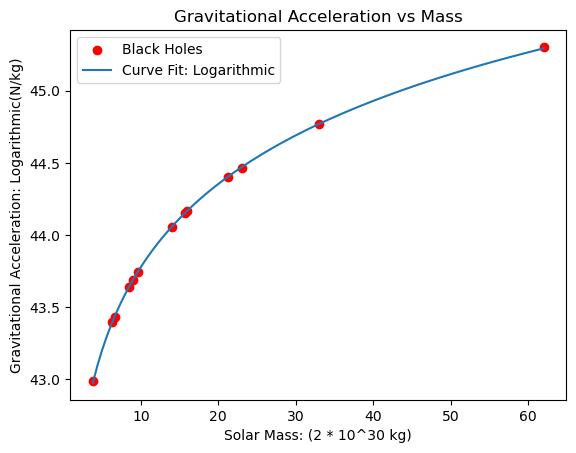

In [11]:
## Graphs ##

# Equations #
def log_fit (x, y, b):
    return y * np.log(x) + b
def linear_fit (x, y, b):
    return x * y + b

# First Curve Fit #
popt, pcov = curve_fit(log_fit, df['Solar Mass'], df['Gravitational Acceleration (Logarithmic: N/kg)'])
y, b = popt
x_fit = np.linspace(min(df['Solar Mass']), max(df['Solar Mass']), 100)
y_fit = log_fit(x_fit, *popt)

# First Graph #
plt.scatter(df['Solar Mass'], df['Gravitational Acceleration (Logarithmic: N/kg)'], color = 'red', label = 'Black Holes')
plt.plot(x_fit, y_fit, label = 'Curve Fit: Logarithmic')
plt.xlabel('Solar Mass: (2 * 10^30 kg)')
plt.ylabel('Gravitational Acceleration: Logarithmic(N/kg)')
plt.title('Gravitational Acceleration vs Mass')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

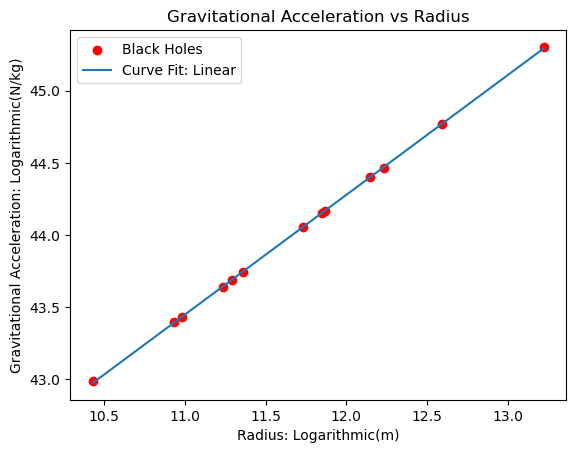

In [12]:
# Second Curve Fit #
popt, pcov = curve_fit(linear_fit, df['Radius (Logarithmic: m)'], df['Gravitational Acceleration (Logarithmic: N/kg)'])
y, b = popt
x_fit = np.linspace(min(df['Radius (Logarithmic: m)']), max(df['Radius (Logarithmic: m)']), 100)
y_fit = linear_fit(x_fit, *popt)

# Second Graph #
plt.scatter(df['Radius (Logarithmic: m)'], df['Gravitational Acceleration (Logarithmic: N/kg)'], color = 'red', label = 'Black Holes')
plt.plot(x_fit, y_fit, label = 'Curve Fit: Linear')
plt.xlabel('Radius: Logarithmic(m)')
plt.ylabel('Gravitational Acceleration: Logarithmic(N/kg)')
plt.title('Gravitational Acceleration vs Radius')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

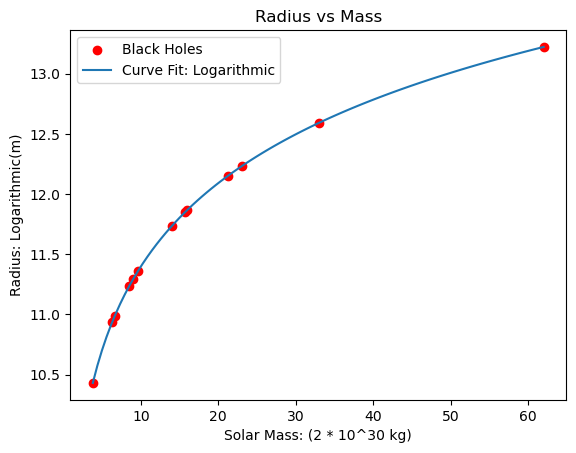

In [13]:
# Third Curve Fit #
popt, pcov = curve_fit(log_fit, df['Solar Mass'], df['Radius (Logarithmic: m)'])
y, b = popt
x_fit = np.linspace(min(df['Solar Mass']), max(df['Solar Mass']), 100)
y_fit = log_fit(x_fit, *popt)

# Third Graph #
plt.scatter(df['Solar Mass'], df['Radius (Logarithmic: m)'], color = 'red', label = 'Black Holes')
plt.plot(x_fit, y_fit, label = 'Curve Fit: Logarithmic')
plt.xlabel('Solar Mass: (2 * 10^30 kg)')
plt.ylabel('Radius: Logarithmic(m)')
plt.title('Radius vs Mass')
plt.legend()
plt.show